# Prévision de la Température et de l'Irradiation Solaire — Benguerir (2026–2055)

## Pipeline LSTM Bidirectionnel — Deep Learning uniquement

**Données** : NASA POWER — T2M (°C) + ALLSKY (W/m²) — 2001 à 2025  
**Modèle** : LSTM Bidirectionnel + Lag Features + Prévision Autorégressive  
**Split** : 80% Train / 20% Test (chronologique)  
**Entraînement** : batch_size = 16 (meilleure capture des patterns fins)  
**Prédiction** : batch_size = 32 (plus rapide, stable)  
**Prévision** : 30 ans (2026–2055) — autorégressive avec mise à jour dynamique des lags

**Variables prédites :**
- **T2M** : Température à 2 mètres (°C)
- **ALLSKY** : Irradiation solaire All-Sky Surface Shortwave Downward (W/m²)


## 1. Imports et Configuration


In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import gc
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

np.random.seed(42)
tf.random.set_seed(42)

# Vérification GPU + configuration mémoire
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"✓ GPU détecté : {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠ Aucun GPU détecté — exécution CPU (plus lent pour LSTM)")

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}") 


✓ GPU détecté : /physical_device:GPU:0
TensorFlow : 2.10.0
NumPy      : 1.26.4
Pandas     : 2.3.3


## 2. Chargement des Données


In [3]:
df = pd.read_csv("data_horaire.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime")

print(f"Données : {len(df)} heures | {df.index[0]} → {df.index[-1]}")
print(f"T2M   — Min={df['T2M'].min():.1f}°C | Max={df['T2M'].max():.1f}°C | Moy={df['T2M'].mean():.1f}°C")
print(f"ALLSKY — Min={df['ALLSKY'].min():.1f} | Max={df['ALLSKY'].max():.1f} | Moy={df['ALLSKY'].mean():.1f} W/m²")
print(f"\nNaN : T2M={df['T2M'].isna().sum()}, ALLSKY={df['ALLSKY'].isna().sum()}")

# ── Traitement des NaN ALLSKY (nov-déc 2025) ─────────────────────
df["ALLSKY"] = df["ALLSKY"].interpolate(method="linear", limit=48)
remaining_nan = df["ALLSKY"].isna().sum()
print(f"Après interpolation (limit=48h) : {remaining_nan} NaN restants → remplissage par moyenne horaire mensuelle")

# Remplir les NaN restants par la moyenne horaire du même mois (années précédentes)
df["_month"] = df.index.month
df["_hour"] = df.index.hour
monthly_hourly_mean = df.groupby(["_month", "_hour"])["ALLSKY"].transform("mean")
df["ALLSKY"] = df["ALLSKY"].fillna(monthly_hourly_mean)
df = df.drop(columns=["_month", "_hour"])

print(f"NaN après remplissage complet : T2M={df['T2M'].isna().sum()}, ALLSKY={df['ALLSKY'].isna().sum()}")
df.head()


Données : 219144 heures | 2001-01-01 00:00:00 → 2025-12-31 23:00:00
T2M   — Min=-3.4°C | Max=47.5°C | Moy=19.9°C
ALLSKY — Min=0.0 | Max=1065.6 | Moy=234.0 W/m²

NaN : T2M=0, ALLSKY=762
Après interpolation (limit=48h) : 714 NaN restants → remplissage par moyenne horaire mensuelle
NaN après remplissage complet : T2M=0, ALLSKY=0


,ALLSKY,T2M
datetime,,
2001-01-01 00:00:00,0.0,10.04
2001-01-01 01:00:00,0.0,9.89
2001-01-01 02:00:00,0.0,9.91
2001-01-01 03:00:00,0.0,9.98
2001-01-01 04:00:00,0.0,9.85


## 3. Feature Engineering + Fonctions utilitaires

- **Encodage cyclique** : fréquences dominantes 24h, 168h, 365.25 jours
- **Indicateurs solaires** : is_daytime, solar_peak, night
- **Saisons** : été / hiver (Benguerir = hémisphère nord)
- **Lag features** : 1h, 2h, 3h, 6h, 12h, 24h, 48h, 72h
- **Rolling features** : moyennes glissantes 24h/72h + écart-type 24h


In [4]:
def create_features(dataframe):
    """Features temporelles issues de l'analyse statistique."""
    d = dataframe.copy()
    idx = d.index

    # Features temporelles brutes
    d["hour"]         = idx.hour
    d["day_of_week"]  = idx.dayofweek
    d["month"]        = idx.month
    d["day_of_year"]  = idx.dayofyear
    d["week_of_year"] = idx.isocalendar().week.astype(int).values
    d["quarter"]      = idx.quarter

    # Encodage cyclique
    d["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
    d["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
    d["dow_sin"]  = np.sin(2 * np.pi * idx.dayofweek / 7)
    d["dow_cos"]  = np.cos(2 * np.pi * idx.dayofweek / 7)
    d["moy_sin"]  = np.sin(2 * np.pi * idx.month / 12)
    d["moy_cos"]  = np.cos(2 * np.pi * idx.month / 12)
    d["doy_sin"]  = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    d["doy_cos"]  = np.cos(2 * np.pi * idx.dayofyear / 365.25)

    # Indicateurs solaires
    d["is_daytime"]   = ((idx.hour >= 6) & (idx.hour <= 19)).astype(int)
    d["solar_peak"]   = ((idx.hour >= 10) & (idx.hour <= 15)).astype(int)
    d["night"]        = ((idx.hour >= 21) | (idx.hour <= 4)).astype(int)

    # Saisons
    d["is_summer"] = ((idx.month >= 6) & (idx.month <= 8)).astype(int)
    d["is_winter"] = ((idx.month == 12) | (idx.month <= 2)).astype(int)

    # Interactions croisées
    d["hour_x_month"]  = d["hour"] * d["month"]
    d["hour_x_summer"] = d["hour"] * d["is_summer"]

    return d


def create_features_with_lags(dataframe, target_col):
    """Features temporelles + lag features pour le LSTM dynamique."""
    d = create_features(dataframe)

    for lag in [1, 2, 3, 6, 12, 24, 48, 72]:
        d[f"lag_{lag}h"] = d[target_col].shift(lag)

    d["rolling_24h_mean"] = d[target_col].rolling(24, min_periods=1).mean()
    d["rolling_72h_mean"] = d[target_col].rolling(72, min_periods=1).mean()
    d["rolling_24h_std"]  = d[target_col].rolling(24, min_periods=1).std().fillna(0)

    d = d.dropna()
    return d


def calc_metrics(y_true, y_pred):
    """Calcule R², RMSE et MAE."""
    return {
        "R²":   r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":  mean_absolute_error(y_true, y_pred)
    }


def make_sequences(X, y, lookback):
    """Crée les séquences (lookback, features) pour le LSTM."""
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


def safe_predict(model, X, batch_size=32):
    """Prédiction par batchs pour éviter OOM GPU."""
    preds = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i+batch_size]
        preds.append(model.predict(batch, verbose=0))
    return np.vstack(preds)


def build_bilstm(lookback, n_features):
    """Construit le modèle BiLSTM(128→64) + LSTM(32) + Dense(64→32→1)."""
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=(lookback, n_features)),
        Dropout(0.3),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.2),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
        loss=Huber(delta=1.0),
        metrics=["mae"]
    )
    return model


print("✓ Toutes les fonctions définies")
print("  Architecture : BiLSTM(128) → BiLSTM(64) → LSTM(32) → Dense(64) → Dense(32) → Dense(1)")
print("  Entraînement : batch_size=16 | Prédiction : batch_size=32")


✓ Toutes les fonctions définies
  Architecture : BiLSTM(128) → BiLSTM(64) → LSTM(32) → Dense(64) → Dense(32) → Dense(1)
  Entraînement : batch_size=16 | Prédiction : batch_size=32


---
# ════════════════════════════════════════════════════════════════
# PARTIE A — PRÉVISION DE LA TEMPÉRATURE (T2M)
# ════════════════════════════════════════════════════════════════


## 4. Préparation des données LSTM — T2M


In [5]:
LOOKBACK = 72  # 3 jours (cycles dominants 24h de l'analyse spectrale)

# Dataset enrichi avec lags pour T2M
df_feat_lag_t = create_features_with_lags(df[["T2M"]], "T2M")
feature_cols_lag_t = [c for c in df_feat_lag_t.columns if c != "T2M"]

print(f"Features avec lags T2M : {len(feature_cols_lag_t)}")
print(f"Lag/Rolling features : {[c for c in feature_cols_lag_t if 'lag' in c or 'rolling' in c]}")

# Scaling
X_all_lag_t = df_feat_lag_t[feature_cols_lag_t].values
y_all_lag_t = df_feat_lag_t["T2M"].values

scaler_X_t = MinMaxScaler()
scaler_y_t = MinMaxScaler()
X_sc_t = scaler_X_t.fit_transform(X_all_lag_t)
y_sc_t = scaler_y_t.fit_transform(y_all_lag_t.reshape(-1, 1)).flatten()

# Création des séquences
X_seq_t, y_seq_t = make_sequences(X_sc_t, y_sc_t, LOOKBACK)

# Split temporel 80/20
sp_t = int(len(X_seq_t) * 0.8)
X_tr_lstm_t, X_te_lstm_t = X_seq_t[:sp_t], X_seq_t[sp_t:]
y_tr_lstm_t, y_te_lstm_t = y_seq_t[:sp_t], y_seq_t[sp_t:]

print(f"\nLookback = {LOOKBACK}h")
print(f"Train : {X_tr_lstm_t.shape}  |  Test : {X_te_lstm_t.shape}")


Features avec lags T2M : 32
Lag/Rolling features : ['lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_72h', 'rolling_24h_mean', 'rolling_72h_mean', 'rolling_24h_std']

Lookback = 72h
Train : (175200, 72, 32)  |  Test : (43800, 72, 32)


## 5. Architecture et Entraînement LSTM — T2M


In [6]:
model_lstm_t = build_bilstm(LOOKBACK, len(feature_cols_lag_t))
model_lstm_t.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirectiona  (None, 72, 256)          164864    
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 72, 256)           0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 72, 128)          164352    
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 72, 128)           0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                20608     
                                                                 
 dropout_2 (Dropout)         (None, 32)                0

In [ ]:
print("Entraînement LSTM T2M (batch_size=16)...")

history_t = model_lstm_t.fit(
    X_tr_lstm_t, y_tr_lstm_t,
    validation_data=(X_te_lstm_t, y_te_lstm_t),
    epochs=50, batch_size=16,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-9, verbose=1)
    ],
    verbose=2
)


Entraînement LSTM T2M (batch_size=16)...
Epoch 1/50
10950/10950 - 435s - loss: 6.1041e-04 - mae: 0.0256 - val_loss: 5.2635e-04 - val_mae: 0.0243 - lr: 0.0010 - 435s/epoch - 40ms/step
Epoch 2/50
10950/10950 - 414s - loss: 2.6600e-04 - mae: 0.0177 - val_loss: 6.1698e-04 - val_mae: 0.0261 - lr: 0.0010 - 414s/epoch - 38ms/step
Epoch 3/50
10950/10950 - 446s - loss: 1.9686e-04 - mae: 0.0151 - val_loss: 6.7874e-04 - val_mae: 0.0269 - lr: 0.0010 - 446s/epoch - 41ms/step
Epoch 4/50

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
10950/10950 - 428s - loss: 1.6412e-04 - mae: 0.0138 - val_loss: 6.9425e-04 - val_mae: 0.0287 - lr: 0.0010 - 428s/epoch - 39ms/step
Epoch 5/50
10950/10950 - 401s - loss: 1.2151e-04 - mae: 0.0117 - val_loss: 6.9671e-04 - val_mae: 0.0280 - lr: 5.0000e-04 - 401s/epoch - 37ms/step
Epoch 6/50
10950/10950 - 408s - loss: 1.1554e-04 - mae: 0.0114 - val_loss: 9.0970e-04 - val_mae: 0.0324 - lr: 5.0000e-04 - 408s/epoch - 37ms/step
Epoch 7/50

Epoch 7: R

## 6. Courbes d'apprentissage & Métriques — T2M


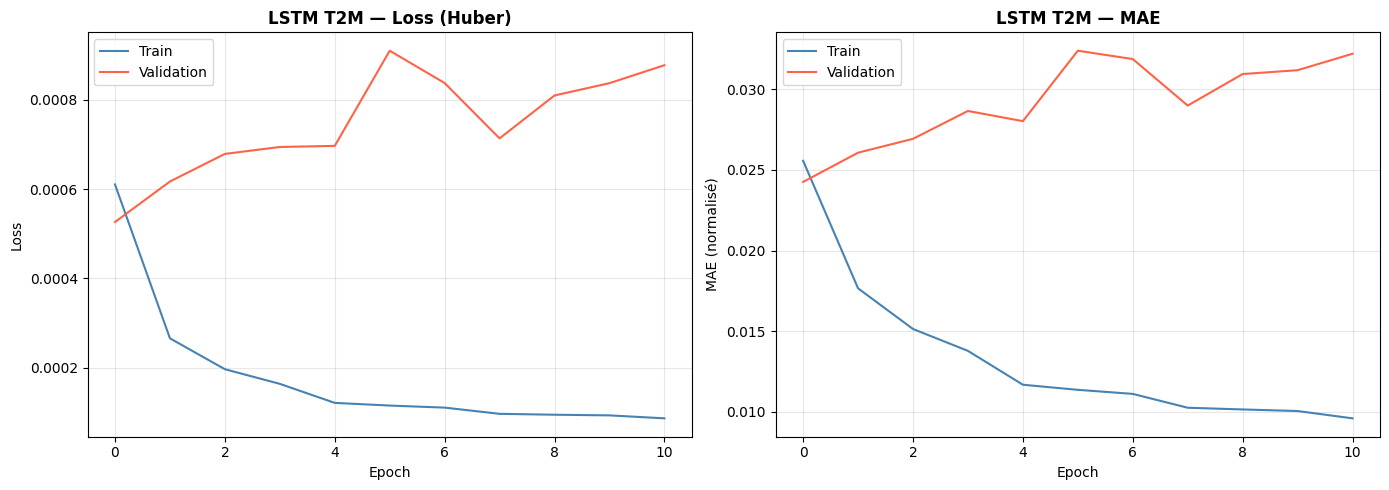

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_t.history["loss"], label="Train", color="steelblue")
axes[0].plot(history_t.history["val_loss"], label="Validation", color="tomato")
axes[0].set_title("LSTM T2M — Loss (Huber)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_t.history["mae"], label="Train", color="steelblue")
axes[1].plot(history_t.history["val_mae"], label="Validation", color="tomato")
axes[1].set_title("LSTM T2M — MAE", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (normalisé)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [9]:
# Libérer mémoire GPU après entraînement
gc.collect()

# Prédiction par batchs de 32 (évite OOM GPU)
ytr_lstm_t = scaler_y_t.inverse_transform(safe_predict(model_lstm_t, X_tr_lstm_t, batch_size=32).reshape(-1, 1)).flatten()
yte_lstm_t = scaler_y_t.inverse_transform(safe_predict(model_lstm_t, X_te_lstm_t, batch_size=32).reshape(-1, 1)).flatten()
ytr_real_t = scaler_y_t.inverse_transform(y_tr_lstm_t.reshape(-1, 1)).flatten()
yte_real_t = scaler_y_t.inverse_transform(y_te_lstm_t.reshape(-1, 1)).flatten()

lstm_train_mt = calc_metrics(ytr_real_t, ytr_lstm_t)
lstm_test_mt  = calc_metrics(yte_real_t, yte_lstm_t)

print(f"╔{'═'*62}╗")
print(f"║  MÉTRIQUES LSTM T2M — TRAIN + TEST{' '*26}║")
print(f"╚{'═'*62}╝")
print(f"  TRAIN →  R²={lstm_train_mt['R²']:.4f}  |  RMSE={lstm_train_mt['RMSE']:.4f} °C  |  MAE={lstm_train_mt['MAE']:.4f} °C")
print(f"  TEST  →  R²={lstm_test_mt['R²']:.4f}  |  RMSE={lstm_test_mt['RMSE']:.4f} °C  |  MAE={lstm_test_mt['MAE']:.4f} °C")


╔══════════════════════════════════════════════════════════════╗
║  MÉTRIQUES LSTM T2M — TRAIN + TEST                          ║
╚══════════════════════════════════════════════════════════════╝
  TRAIN →  R²=0.9667  |  RMSE=1.5638 °C  |  MAE=1.1666 °C
  TEST  →  R²=0.9613  |  RMSE=1.6502 °C  |  MAE=1.2339 °C


## 7. Visualisation LSTM — T2M


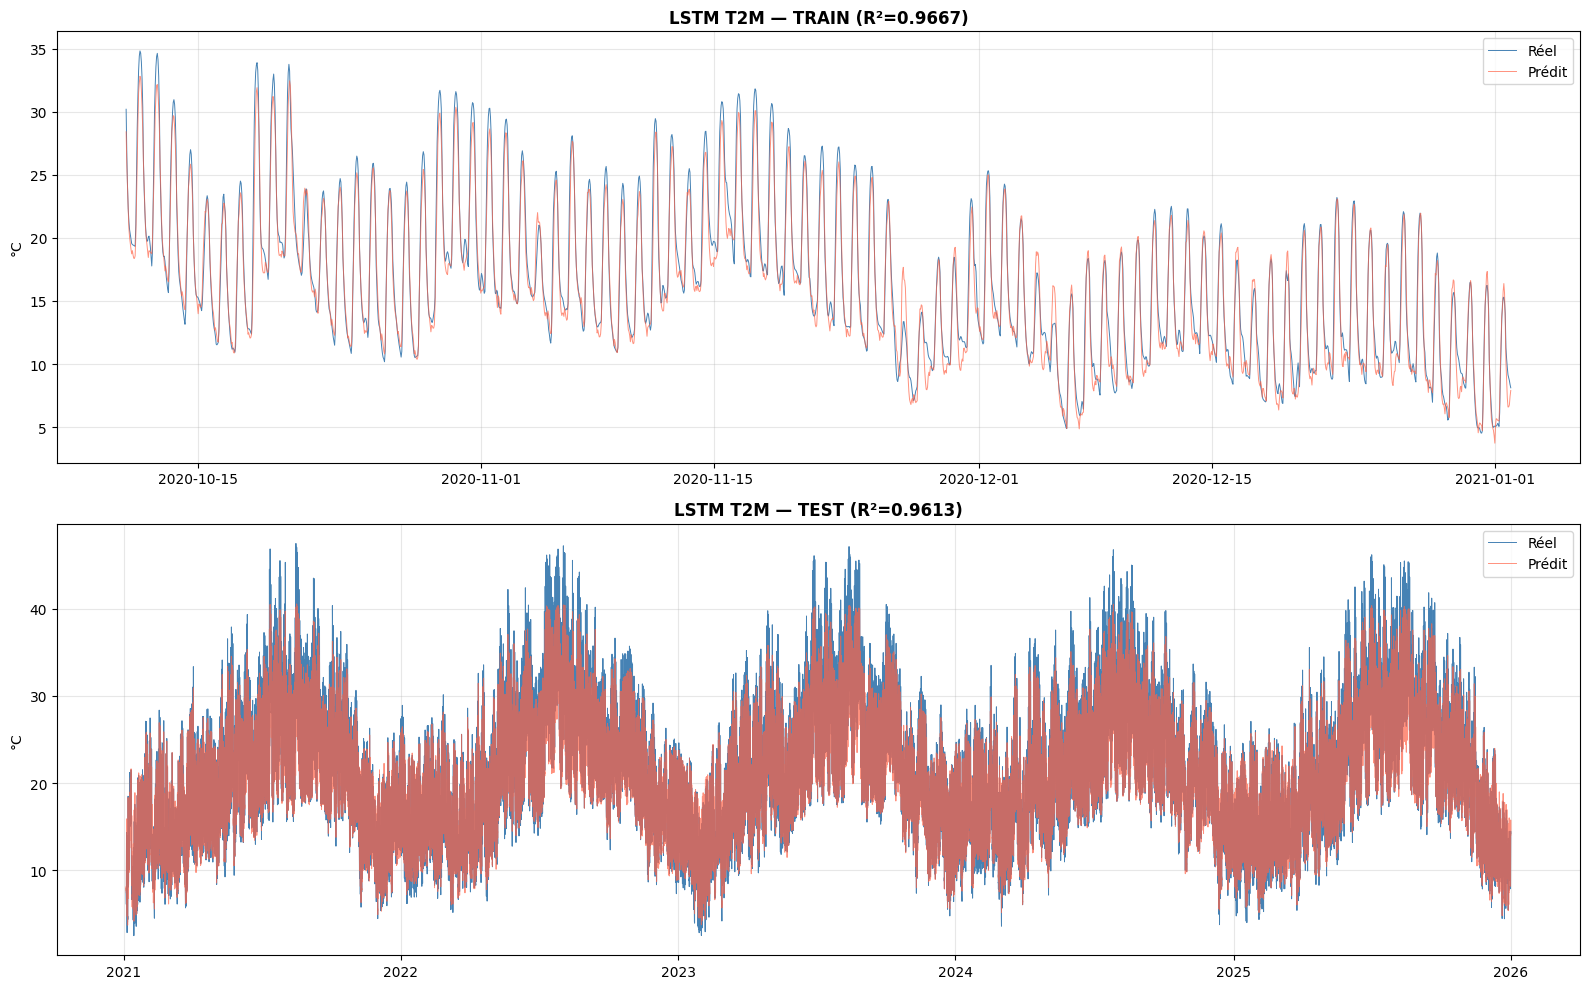

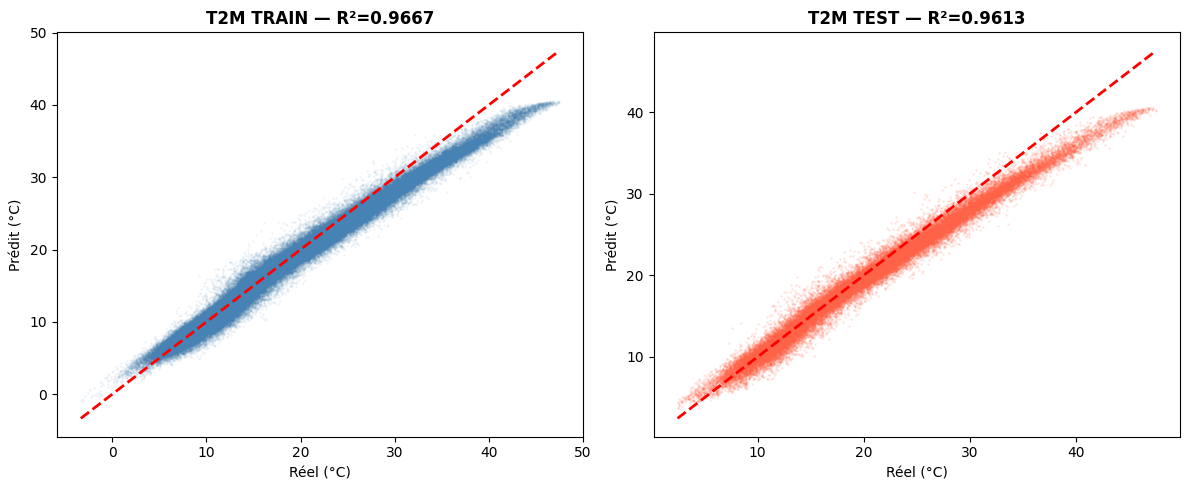

In [10]:
split_idx_lag_t = int(len(df_feat_lag_t) * 0.8)
train_idx_lstm_t = df_feat_lag_t.index[LOOKBACK:LOOKBACK + len(ytr_real_t)]
test_idx_lstm_t  = df_feat_lag_t.index[split_idx_lag_t + LOOKBACK:][:len(yte_real_t)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(train_idx_lstm_t[-2000:], ytr_real_t[-2000:], lw=0.7, color="steelblue", label="Réel")
axes[0].plot(train_idx_lstm_t[-2000:], ytr_lstm_t[-2000:], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[0].set_title(f"LSTM T2M — TRAIN (R²={lstm_train_mt['R²']:.4f})", fontweight="bold")
axes[0].legend(); axes[0].set_ylabel("°C"); axes[0].grid(True, alpha=0.3)

n_te = min(len(test_idx_lstm_t), len(yte_real_t))
axes[1].plot(test_idx_lstm_t[:n_te], yte_real_t[:n_te], lw=0.7, color="steelblue", label="Réel")
axes[1].plot(test_idx_lstm_t[:n_te], yte_lstm_t[:n_te], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[1].set_title(f"LSTM T2M — TEST (R²={lstm_test_mt['R²']:.4f})", fontweight="bold")
axes[1].legend(); axes[1].set_ylabel("°C"); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Scatter plot Réel vs Prédit
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(ytr_real_t, ytr_lstm_t, s=1, alpha=0.05, color="steelblue")
axes[0].plot([ytr_real_t.min(), ytr_real_t.max()], [ytr_real_t.min(), ytr_real_t.max()], "r--", lw=2)
axes[0].set_xlabel("Réel (°C)"); axes[0].set_ylabel("Prédit (°C)")
axes[0].set_title(f"T2M TRAIN — R²={lstm_train_mt['R²']:.4f}", fontweight="bold")

axes[1].scatter(yte_real_t, yte_lstm_t, s=1, alpha=0.1, color="tomato")
axes[1].plot([yte_real_t.min(), yte_real_t.max()], [yte_real_t.min(), yte_real_t.max()], "r--", lw=2)
axes[1].set_xlabel("Réel (°C)"); axes[1].set_ylabel("Prédit (°C)")
axes[1].set_title(f"T2M TEST — R²={lstm_test_mt['R²']:.4f}", fontweight="bold")

plt.tight_layout(); plt.show()


---
# ════════════════════════════════════════════════════════════════
# PARTIE B — PRÉVISION DE L'IRRADIATION SOLAIRE (ALLSKY)
# ════════════════════════════════════════════════════════════════


## 8. Préparation des données LSTM — ALLSKY


In [ ]:
# Dataset enrichi avec lags pour ALLSKY
df_feat_lag_s = create_features_with_lags(df[["ALLSKY"]], "ALLSKY")
feature_cols_lag_s = [c for c in df_feat_lag_s.columns if c != "ALLSKY"]

print(f"Features avec lags ALLSKY : {len(feature_cols_lag_s)}")

# Scaling
X_all_lag_s = df_feat_lag_s[feature_cols_lag_s].values
y_all_lag_s = df_feat_lag_s["ALLSKY"].values

scaler_X_s = MinMaxScaler()
scaler_y_s = MinMaxScaler()
X_sc_s = scaler_X_s.fit_transform(X_all_lag_s)
y_sc_s = scaler_y_s.fit_transform(y_all_lag_s.reshape(-1, 1)).flatten()

X_seq_s, y_seq_s = make_sequences(X_sc_s, y_sc_s, LOOKBACK)

sp_s = int(len(X_seq_s) * 0.8)
X_tr_lstm_s, X_te_lstm_s = X_seq_s[:sp_s], X_seq_s[sp_s:]
y_tr_lstm_s, y_te_lstm_s = y_seq_s[:sp_s], y_seq_s[sp_s:]

print(f"Train : {X_tr_lstm_s.shape}  |  Test : {X_te_lstm_s.shape}")


Features avec lags ALLSKY : 32
Train : (175200, 72, 32)  |  Test : (43800, 72, 32)


## 9. Architecture et Entraînement LSTM — ALLSKY


In [12]:
# Libérer mémoire du modèle T2M avant de construire celui d'ALLSKY
gc.collect()

model_lstm_s = build_bilstm(LOOKBACK, len(feature_cols_lag_s))

print("Entraînement LSTM ALLSKY (batch_size=16)...")
history_s = model_lstm_s.fit(
    X_tr_lstm_s, y_tr_lstm_s,
    validation_data=(X_te_lstm_s, y_te_lstm_s),
    epochs=50, batch_size=16,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-9, verbose=1)
    ],
    verbose=2
)


Entraînement LSTM ALLSKY (batch_size=16)...
Epoch 1/50
10950/10950 - 424s - loss: 0.0012 - mae: 0.0274 - val_loss: 8.6066e-04 - val_mae: 0.0246 - lr: 0.0010 - 424s/epoch - 39ms/step
Epoch 2/50
10950/10950 - 435s - loss: 6.6765e-04 - mae: 0.0197 - val_loss: 8.0054e-04 - val_mae: 0.0241 - lr: 0.0010 - 435s/epoch - 40ms/step
Epoch 3/50
10950/10950 - 430s - loss: 5.7894e-04 - mae: 0.0177 - val_loss: 7.6871e-04 - val_mae: 0.0266 - lr: 0.0010 - 430s/epoch - 39ms/step
Epoch 4/50

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
10950/10950 - 420s - loss: 5.3176e-04 - mae: 0.0167 - val_loss: 0.0013 - val_mae: 0.0388 - lr: 0.0010 - 420s/epoch - 38ms/step
Epoch 5/50
10950/10950 - 420s - loss: 4.5123e-04 - mae: 0.0144 - val_loss: 8.8642e-04 - val_mae: 0.0339 - lr: 5.0000e-04 - 420s/epoch - 38ms/step
Epoch 6/50
10950/10950 - 410s - loss: 4.4092e-04 - mae: 0.0141 - val_loss: 0.0011 - val_mae: 0.0375 - lr: 5.0000e-04 - 410s/epoch - 37ms/step
Epoch 7/50

Epoch 7: ReduceLROn

## 10. Courbes d'apprentissage & Métriques — ALLSKY


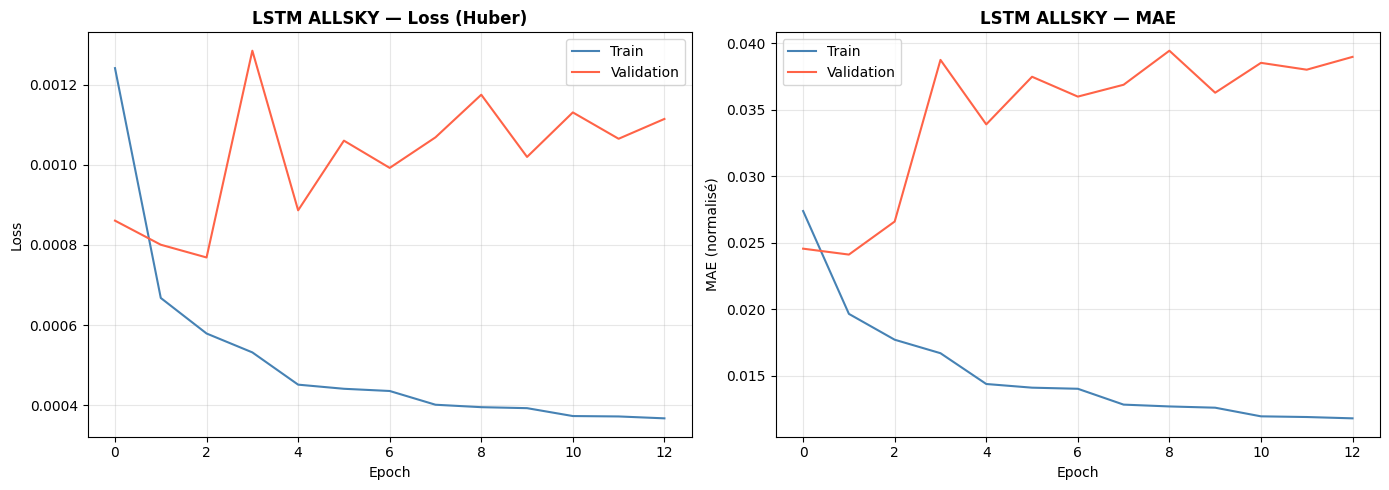

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_s.history["loss"], label="Train", color="steelblue")
axes[0].plot(history_s.history["val_loss"], label="Validation", color="tomato")
axes[0].set_title("LSTM ALLSKY — Loss (Huber)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_s.history["mae"], label="Train", color="steelblue")
axes[1].plot(history_s.history["val_mae"], label="Validation", color="tomato")
axes[1].set_title("LSTM ALLSKY — MAE", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (normalisé)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [14]:
# Libérer mémoire GPU
gc.collect()

# Prédiction par batchs de 32
ytr_lstm_s = scaler_y_s.inverse_transform(safe_predict(model_lstm_s, X_tr_lstm_s, batch_size=32).reshape(-1, 1)).flatten()
yte_lstm_s = scaler_y_s.inverse_transform(safe_predict(model_lstm_s, X_te_lstm_s, batch_size=32).reshape(-1, 1)).flatten()
ytr_real_s = scaler_y_s.inverse_transform(y_tr_lstm_s.reshape(-1, 1)).flatten()
yte_real_s = scaler_y_s.inverse_transform(y_te_lstm_s.reshape(-1, 1)).flatten()

# Clamp ≥ 0 (irradiation ne peut pas être négative)
ytr_lstm_s = np.maximum(ytr_lstm_s, 0)
yte_lstm_s = np.maximum(yte_lstm_s, 0)

lstm_train_ms = calc_metrics(ytr_real_s, ytr_lstm_s)
lstm_test_ms  = calc_metrics(yte_real_s, yte_lstm_s)

print(f"╔{'═'*62}╗")
print(f"║  MÉTRIQUES LSTM ALLSKY — TRAIN + TEST{' '*23}║")
print(f"╚{'═'*62}╝")
print(f"  TRAIN →  R²={lstm_train_ms['R²']:.4f}  |  RMSE={lstm_train_ms['RMSE']:.2f} W/m²  |  MAE={lstm_train_ms['MAE']:.2f} W/m²")
print(f"  TEST  →  R²={lstm_test_ms['R²']:.4f}  |  RMSE={lstm_test_ms['RMSE']:.2f} W/m²  |  MAE={lstm_test_ms['MAE']:.2f} W/m²")


╔══════════════════════════════════════════════════════════════╗
║  MÉTRIQUES LSTM ALLSKY — TRAIN + TEST                       ║
╚══════════════════════════════════════════════════════════════╝
  TRAIN →  R²=0.9823  |  RMSE=41.67 W/m²  |  MAE=28.41 W/m²
  TEST  →  R²=0.9821  |  RMSE=41.78 W/m²  |  MAE=28.35 W/m²


## 11. Visualisation LSTM — ALLSKY


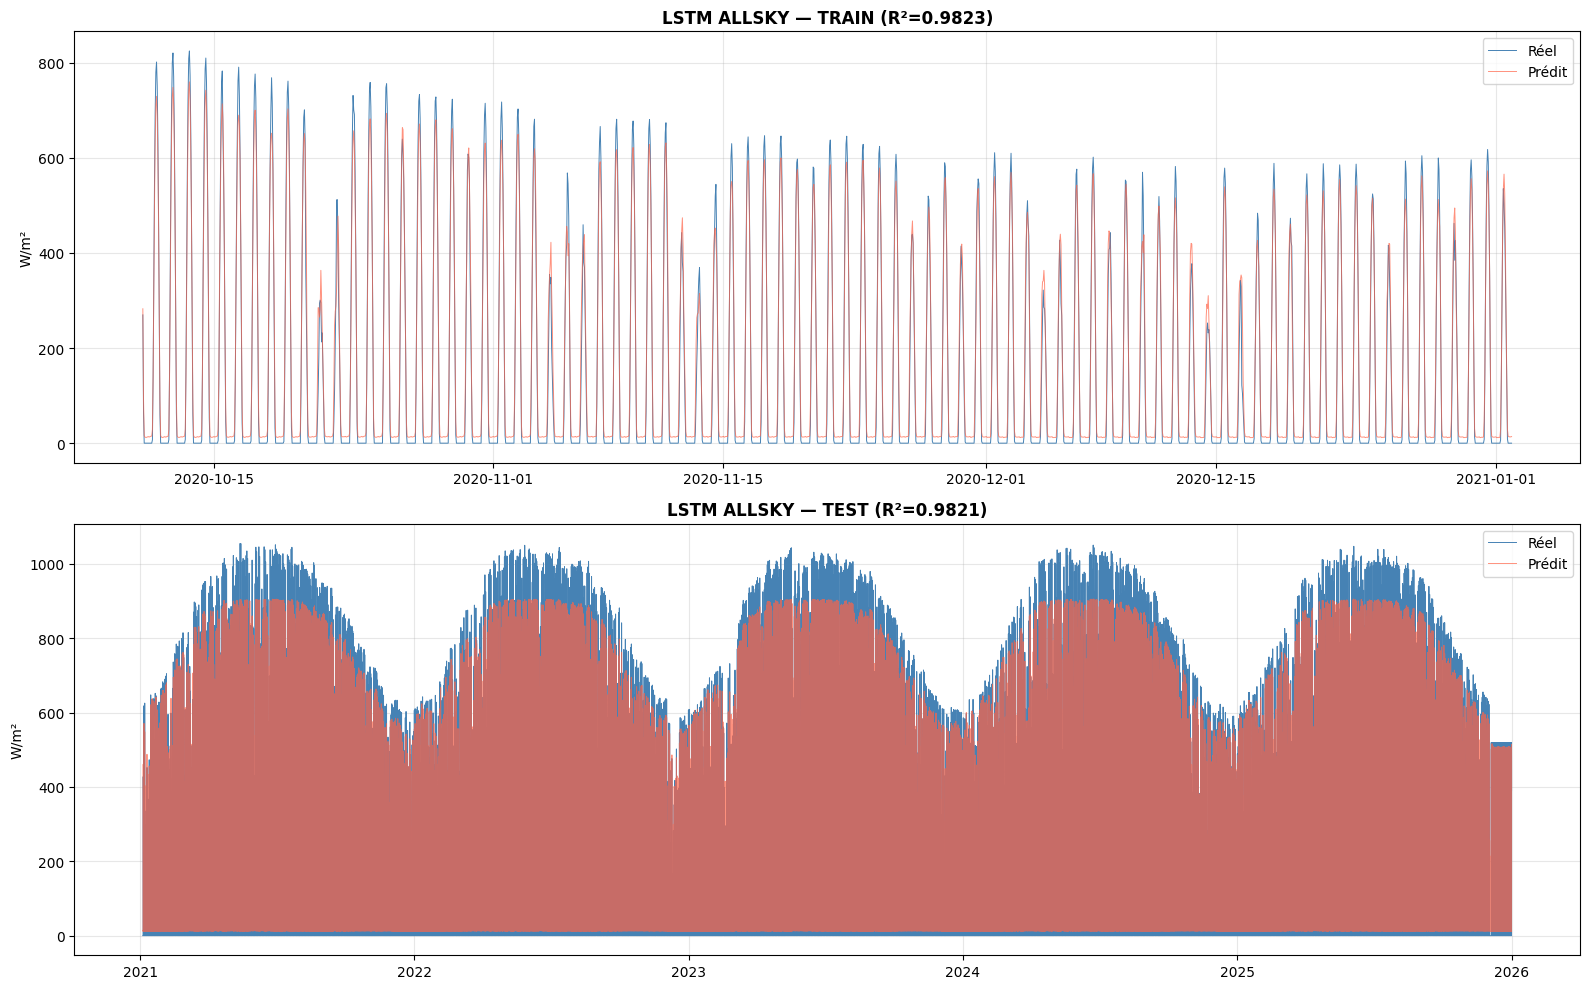

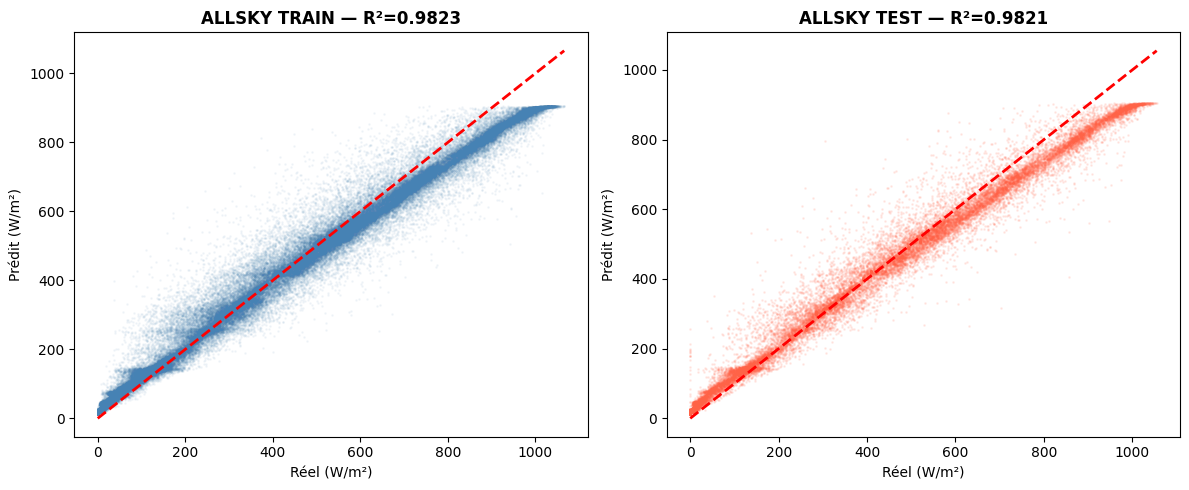

In [15]:
split_idx_lag_s = int(len(df_feat_lag_s) * 0.8)
train_idx_lstm_s = df_feat_lag_s.index[LOOKBACK:LOOKBACK + len(ytr_real_s)]
test_idx_lstm_s  = df_feat_lag_s.index[split_idx_lag_s + LOOKBACK:][:len(yte_real_s)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(train_idx_lstm_s[-2000:], ytr_real_s[-2000:], lw=0.7, color="steelblue", label="Réel")
axes[0].plot(train_idx_lstm_s[-2000:], ytr_lstm_s[-2000:], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[0].set_title(f"LSTM ALLSKY — TRAIN (R²={lstm_train_ms['R²']:.4f})", fontweight="bold")
axes[0].legend(); axes[0].set_ylabel("W/m²"); axes[0].grid(True, alpha=0.3)

n_te_s = min(len(test_idx_lstm_s), len(yte_real_s))
axes[1].plot(test_idx_lstm_s[:n_te_s], yte_real_s[:n_te_s], lw=0.7, color="steelblue", label="Réel")
axes[1].plot(test_idx_lstm_s[:n_te_s], yte_lstm_s[:n_te_s], lw=0.7, color="tomato", alpha=0.7, label="Prédit")
axes[1].set_title(f"LSTM ALLSKY — TEST (R²={lstm_test_ms['R²']:.4f})", fontweight="bold")
axes[1].legend(); axes[1].set_ylabel("W/m²"); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(ytr_real_s, ytr_lstm_s, s=1, alpha=0.05, color="steelblue")
axes[0].plot([0, ytr_real_s.max()], [0, ytr_real_s.max()], "r--", lw=2)
axes[0].set_xlabel("Réel (W/m²)"); axes[0].set_ylabel("Prédit (W/m²)")
axes[0].set_title(f"ALLSKY TRAIN — R²={lstm_train_ms['R²']:.4f}", fontweight="bold")

axes[1].scatter(yte_real_s, yte_lstm_s, s=1, alpha=0.1, color="tomato")
axes[1].plot([0, yte_real_s.max()], [0, yte_real_s.max()], "r--", lw=2)
axes[1].set_xlabel("Réel (W/m²)"); axes[1].set_ylabel("Prédit (W/m²)")
axes[1].set_title(f"ALLSKY TEST — R²={lstm_test_ms['R²']:.4f}", fontweight="bold")

plt.tight_layout(); plt.show()


## 12. Récapitulatif des métriques — T2M & ALLSKY



Variable Dataset     R²    RMSE     MAE
     T2M   Train 0.9667  1.5638  1.1666
     T2M    Test 0.9613  1.6502  1.2339
  ALLSKY   Train 0.9823 41.6681 28.4139
  ALLSKY    Test 0.9821 41.7825 28.3486


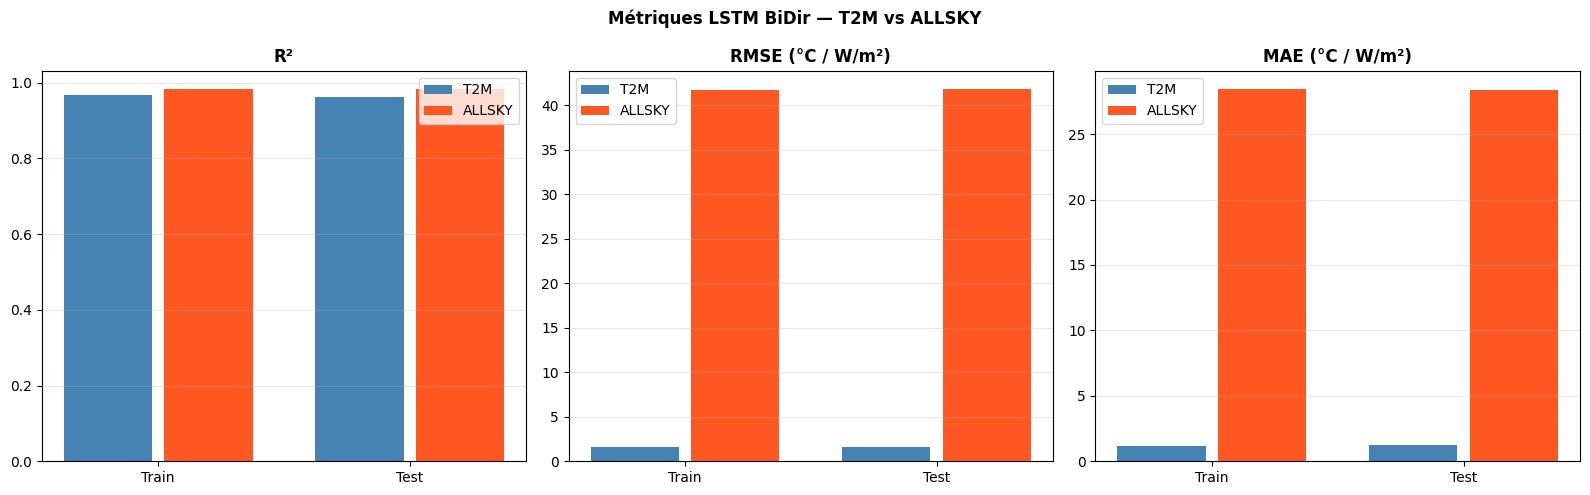

In [16]:
comp = pd.DataFrame({
    "Variable":  ["T2M", "T2M", "ALLSKY", "ALLSKY"],
    "Dataset":   ["Train", "Test", "Train", "Test"],
    "R²":        [lstm_train_mt["R²"], lstm_test_mt["R²"], lstm_train_ms["R²"], lstm_test_ms["R²"]],
    "RMSE":      [lstm_train_mt["RMSE"], lstm_test_mt["RMSE"], lstm_train_ms["RMSE"], lstm_test_ms["RMSE"]],
    "MAE":       [lstm_train_mt["MAE"], lstm_test_mt["MAE"], lstm_train_ms["MAE"], lstm_test_ms["MAE"]]
})

print("\n" + comp.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, met in enumerate(["R²", "RMSE", "MAE"]):
    tv = [lstm_train_mt[met], lstm_test_mt[met]]
    sv = [lstm_train_ms[met], lstm_test_ms[met]]
    x = np.arange(2)
    axes[i].bar(x - 0.2, tv, 0.35, label="T2M", color="steelblue")
    axes[i].bar(x + 0.2, sv, 0.35, label="ALLSKY", color="#FF5722")
    axes[i].set_xticks(x); axes[i].set_xticklabels(["Train", "Test"])
    unit = "" if met == "R²" else " (°C / W/m²)"
    axes[i].set_title(f"{met}{unit}", fontweight="bold")
    axes[i].legend(); axes[i].grid(True, alpha=0.3, axis="y")
plt.suptitle("Métriques LSTM BiDir — T2M vs ALLSKY", fontweight="bold")
plt.tight_layout(); plt.show()


---
# ════════════════════════════════════════════════════════════════
# PARTIE C — PRÉVISION 30 ANS (2026–2055) — LSTM Autorégressive
# ════════════════════════════════════════════════════════════════


In [21]:
def autoregressive_forecast(model, scaler_X, scaler_y, X_sc, feature_cols_lag,
                            df_source, target_col, future_idx, lookback,
                            clamp_min=None, clamp_max=None):
    """
    Prévision autorégressive LSTM — utilise le modèle déjà entraîné.
    Mise à jour dynamique des lags et rolling features à chaque pas.
    Valeurs arrondies à 2 décimales.
    """
    @tf.function(reduce_retracing=True)
    def predict_fast(mdl, x):
        return mdl(x, training=False)
    
    # Warmup
    _ = predict_fast(model, tf.zeros((1, lookback, len(feature_cols_lag)), dtype=tf.float32))
    
    n_future = len(future_idx)
    
    # Features calendaires futures
    df_fut_base = pd.DataFrame(index=future_idx, columns=[target_col])
    df_fut_base[target_col] = 0
    df_fut_base = create_features(df_fut_base)
    calendar_cols = [c for c in df_fut_base.columns if c != target_col]
    future_calendar = df_fut_base[calendar_cols].values
    
    # Historique
    lag_values = [1, 2, 3, 6, 12, 24, 48, 72]
    max_lag = max(lag_values)
    value_history = list(df_source[target_col].values[-max_lag:])
    
    # Mapping d'indices
    lag_col_indices = {col: feature_cols_lag.index(col) for col in feature_cols_lag
                       if "lag" in col or "rolling" in col}
    calendar_col_names = [c for c in feature_cols_lag if c not in lag_col_indices]
    
    cal_col_to_idx = {col: (feature_cols_lag.index(col), calendar_cols.index(col))
                      for col in calendar_col_names if col in calendar_cols}
    lag_col_to_idx = {lag: lag_col_indices[f"lag_{lag}h"]
                      for lag in lag_values if f"lag_{lag}h" in lag_col_indices}
    roll_24_idx = lag_col_indices.get("rolling_24h_mean")
    roll_72_idx = lag_col_indices.get("rolling_72h_mean")
    std_24_idx  = lag_col_indices.get("rolling_24h_std")
    
    window = X_sc[-lookback:].copy()
    
    y_preds = []
    t_start = time.time()
    
    for i in range(n_future):
        input_tensor = tf.constant(window.reshape(1, lookback, -1), dtype=tf.float32)
        pred_scaled = predict_fast(model, input_tensor).numpy()[0, 0]
        pred_real = scaler_y.inverse_transform([[pred_scaled]])[0, 0]
        
        if clamp_min is not None:
            pred_real = max(pred_real, clamp_min)
        if clamp_max is not None:
            pred_real = min(pred_real, clamp_max)
        
        # Arrondir à 2 décimales
        pred_real = round(pred_real, 2)
        
        y_preds.append(pred_real)
        value_history.append(pred_real)
        
        new_row_raw = np.zeros(len(feature_cols_lag))
        
        for col, (feat_idx, cal_idx) in cal_col_to_idx.items():
            new_row_raw[feat_idx] = future_calendar[i, cal_idx]
        
        for lag, col_idx in lag_col_to_idx.items():
            new_row_raw[col_idx] = value_history[-(lag + 1)]
        
        if roll_24_idx is not None:
            new_row_raw[roll_24_idx] = np.mean(value_history[-24:])
        if roll_72_idx is not None:
            new_row_raw[roll_72_idx] = np.mean(value_history[-72:])
        if std_24_idx is not None:
            new_row_raw[std_24_idx] = np.std(value_history[-24:])
        
        new_row_scaled = scaler_X.transform(new_row_raw.reshape(1, -1))[0]
        window = np.vstack([window[1:], new_row_scaled])
        
        if len(value_history) > 10000:
            value_history = value_history[-max_lag - 100:]
        
        if (i + 1) % 8760 == 0:
            elapsed = time.time() - t_start
            year = future_idx[i].year
            speed = (i + 1) / elapsed
            eta = (n_future - i - 1) / speed / 60
            print(f"  → {year} | {i+1:>7,}/{n_future:,} | "
                  f"Moy={np.mean(y_preds[-8760:]):.2f} | "
                  f"{speed:.0f} it/s | ETA {eta:.0f} min")
            gc.collect()
    
    elapsed_total = time.time() - t_start
    y_out = np.array(y_preds)
    
    print(f"\n{'='*60}")
    print(f"  {target_col} | {future_idx[0]} → {future_idx[-1]}")
    print(f"  Nb heures: {len(y_out):,}")
    print(f"  Min={y_out.min():.2f} | Max={y_out.max():.2f} | Moy={y_out.mean():.2f}")
    print(f"  Temps total : {elapsed_total/60:.1f} min")
    print(f"{'='*60}")
    
    return y_out

print("✓ Fonction de prévision autorégressive définie")

✓ Fonction de prévision autorégressive définie


In [22]:
future_idx = pd.date_range("2026-01-01", "2055-12-31 23:00:00", freq="h")
print(f"Horizon : {future_idx[0]} → {future_idx[-1]} ({len(future_idx):,} heures)")

print("\n" + "═"*60)
print("  PRÉVISION AUTORÉGRESSIVE 30 ANS — T2M")
print("  (modèle déjà entraîné — pas de réentraînement)")
print("═"*60)
y_fut_t = autoregressive_forecast(
    model_lstm_t, scaler_X_t, scaler_y_t, X_sc_t, feature_cols_lag_t,
    df, "T2M", future_idx, LOOKBACK,
    clamp_min=-10.0, clamp_max=55.0
)

Horizon : 2026-01-01 00:00:00 → 2055-12-31 23:00:00 (262,968 heures)

════════════════════════════════════════════════════════════
  PRÉVISION AUTORÉGRESSIVE 30 ANS — T2M
  (modèle déjà entraîné — pas de réentraînement)
════════════════════════════════════════════════════════════
  → 2026 |   8,760/262,968 | Moy=14.80 | 71 it/s | ETA 60 min
  → 2027 |  17,520/262,968 | Moy=14.84 | 70 it/s | ETA 59 min
  → 2028 |  26,280/262,968 | Moy=14.83 | 72 it/s | ETA 54 min
  → 2029 |  35,040/262,968 | Moy=14.79 | 74 it/s | ETA 51 min
  → 2030 |  43,800/262,968 | Moy=14.79 | 74 it/s | ETA 49 min
  → 2031 |  52,560/262,968 | Moy=14.78 | 75 it/s | ETA 47 min
  → 2032 |  61,320/262,968 | Moy=14.75 | 75 it/s | ETA 45 min
  → 2033 |  70,080/262,968 | Moy=14.82 | 75 it/s | ETA 43 min
  → 2034 |  78,840/262,968 | Moy=14.82 | 75 it/s | ETA 41 min
  → 2035 |  87,600/262,968 | Moy=14.79 | 75 it/s | ETA 39 min
  → 2036 |  96,360/262,968 | Moy=14.79 | 75 it/s | ETA 37 min
  → 2037 | 105,120/262,968 | Moy=14.7

## 11. Prévision autorégressive 30 ans — ALLSKY

Même principe : le modèle déjà entraîné est utilisé directement.


In [23]:
print("═"*60)
print("  PRÉVISION AUTORÉGRESSIVE 30 ANS — ALLSKY")
print("  (modèle déjà entraîné — pas de réentraînement)")
print("═"*60)

gc.collect()

y_fut_s = autoregressive_forecast(
    model_lstm_s, scaler_X_s, scaler_y_s, X_sc_s, feature_cols_lag_s,
    df, "ALLSKY", future_idx, LOOKBACK,
    clamp_min=0.0, clamp_max=1200.0
)


════════════════════════════════════════════════════════════
  PRÉVISION AUTORÉGRESSIVE 30 ANS — ALLSKY
  (modèle déjà entraîné — pas de réentraînement)
════════════════════════════════════════════════════════════
  → 2026 |   8,760/262,968 | Moy=216.54 | 75 it/s | ETA 56 min
  → 2027 |  17,520/262,968 | Moy=216.93 | 75 it/s | ETA 54 min
  → 2028 |  26,280/262,968 | Moy=216.95 | 76 it/s | ETA 52 min
  → 2029 |  35,040/262,968 | Moy=216.74 | 76 it/s | ETA 50 min
  → 2030 |  43,800/262,968 | Moy=216.70 | 76 it/s | ETA 48 min
  → 2031 |  52,560/262,968 | Moy=216.66 | 76 it/s | ETA 46 min
  → 2032 |  61,320/262,968 | Moy=216.71 | 76 it/s | ETA 44 min
  → 2033 |  70,080/262,968 | Moy=216.88 | 76 it/s | ETA 42 min
  → 2034 |  78,840/262,968 | Moy=216.82 | 76 it/s | ETA 40 min
  → 2035 |  87,600/262,968 | Moy=216.75 | 76 it/s | ETA 39 min
  → 2036 |  96,360/262,968 | Moy=216.80 | 76 it/s | ETA 37 min
  → 2037 | 105,120/262,968 | Moy=216.61 | 77 it/s | ETA 34 min
  → 2038 | 113,880/262,968 | M

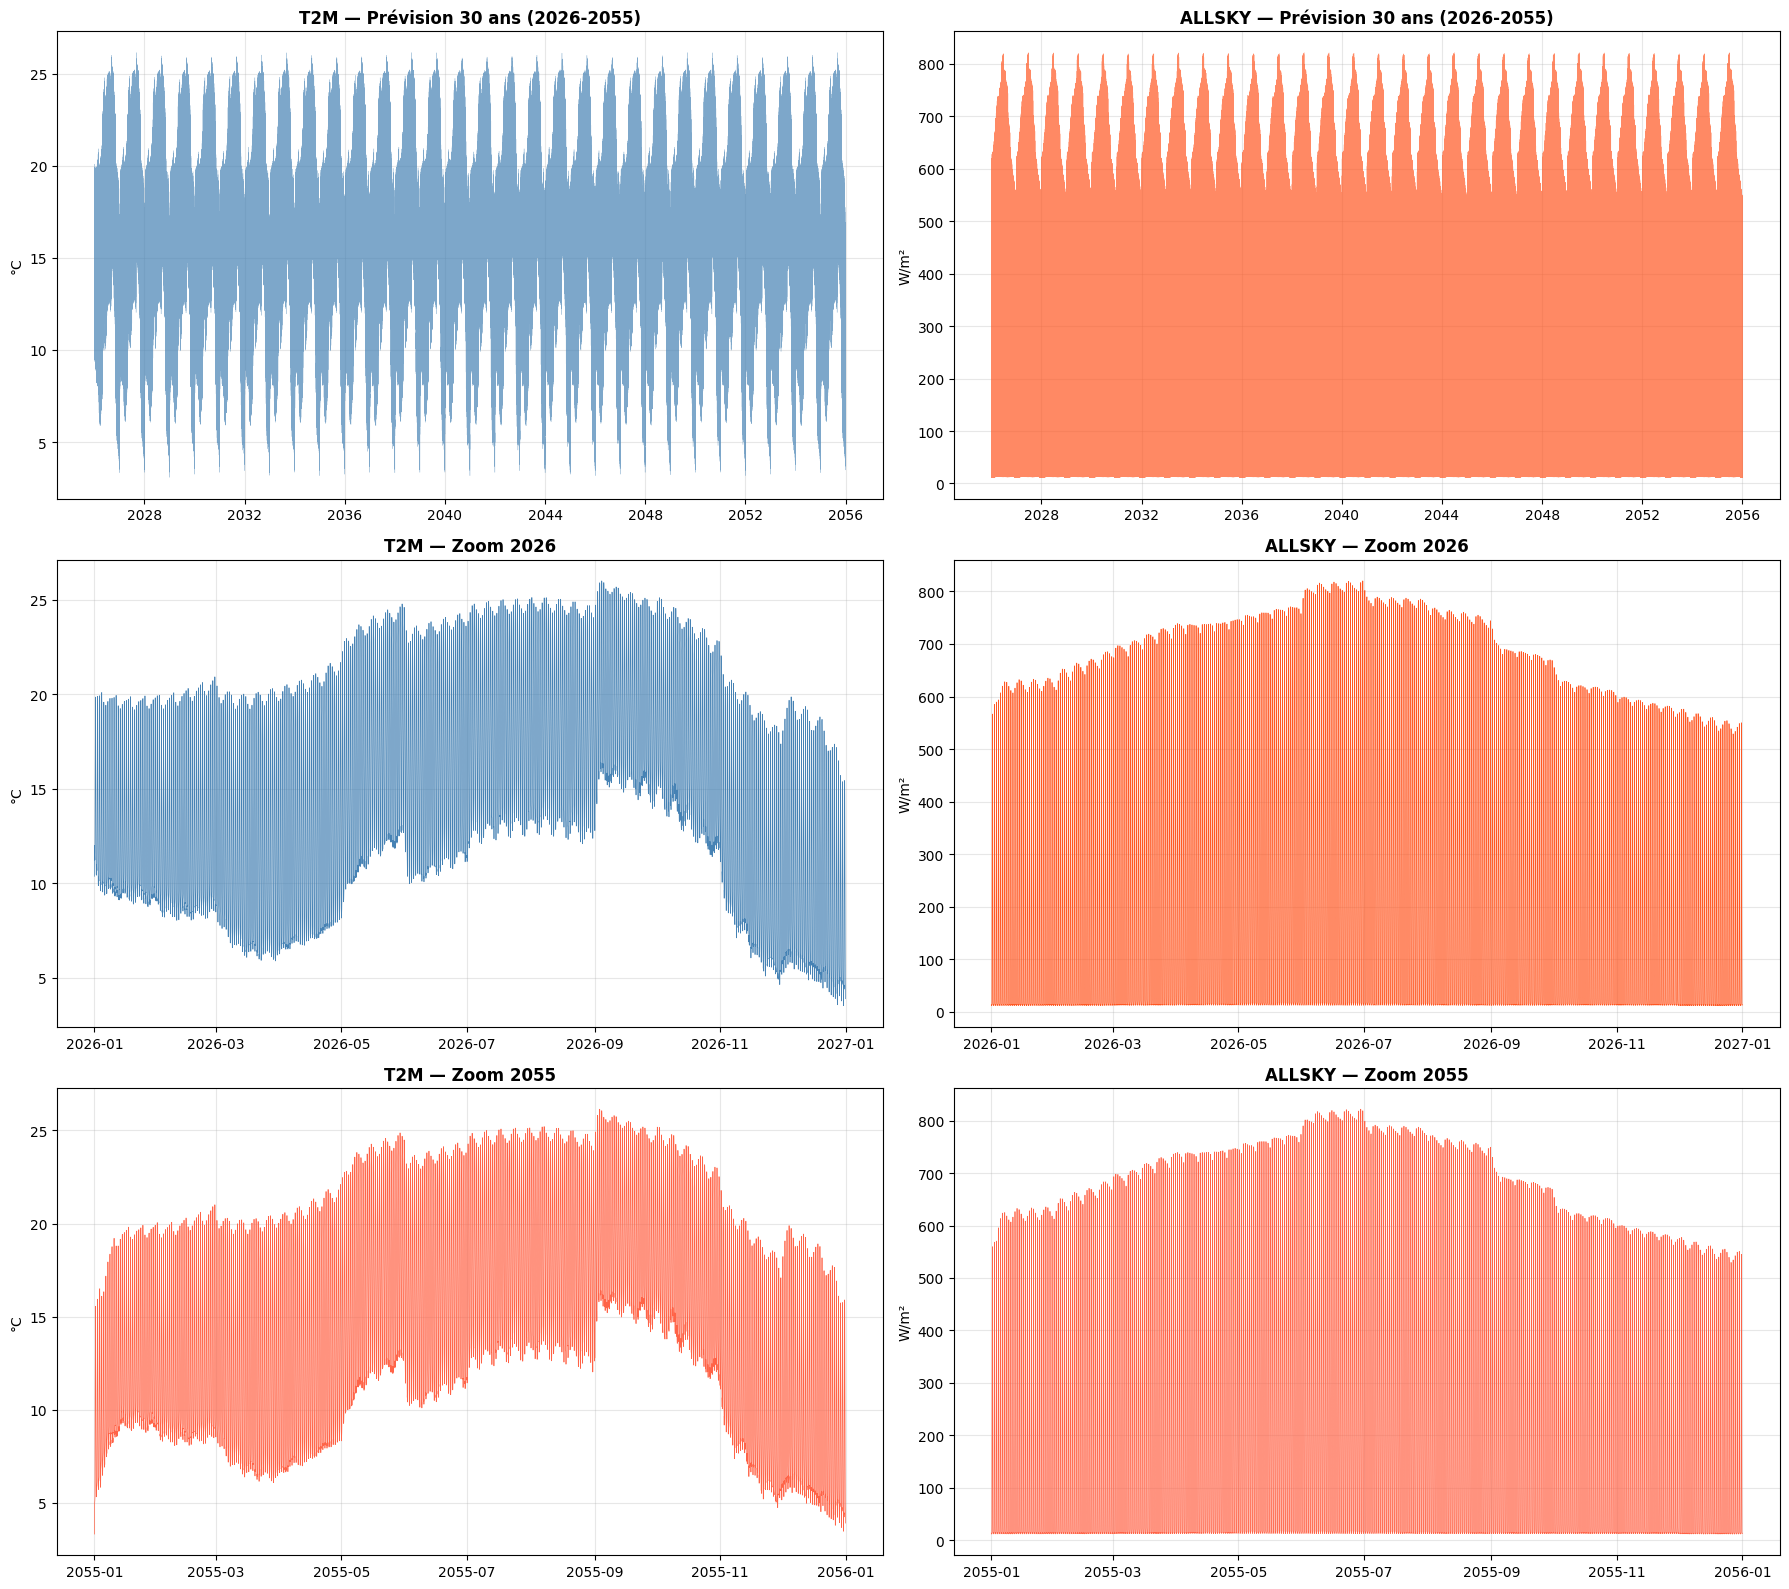

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

axes[0,0].plot(future_idx, y_fut_t, lw=0.2, color="steelblue", alpha=0.7)
axes[0,0].set_title("T2M — Prévision 30 ans (2026-2055)", fontweight="bold")
axes[0,0].set_ylabel("°C"); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(future_idx, y_fut_s, lw=0.2, color="#FF5722", alpha=0.7)
axes[0,1].set_title("ALLSKY — Prévision 30 ans (2026-2055)", fontweight="bold")
axes[0,1].set_ylabel("W/m²"); axes[0,1].grid(True, alpha=0.3)

m2026 = (future_idx.year == 2026)
axes[1,0].plot(future_idx[m2026], y_fut_t[m2026], lw=0.5, color="steelblue")
axes[1,0].set_title("T2M — Zoom 2026", fontweight="bold")
axes[1,0].set_ylabel("°C"); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(future_idx[m2026], y_fut_s[m2026], lw=0.5, color="#FF5722")
axes[1,1].set_title("ALLSKY — Zoom 2026", fontweight="bold")
axes[1,1].set_ylabel("W/m²"); axes[1,1].grid(True, alpha=0.3)

m2055 = (future_idx.year == 2055)
axes[2,0].plot(future_idx[m2055], y_fut_t[m2055], lw=0.5, color="tomato")
axes[2,0].set_title("T2M — Zoom 2055", fontweight="bold")
axes[2,0].set_ylabel("°C"); axes[2,0].grid(True, alpha=0.3)

axes[2,1].plot(future_idx[m2055], y_fut_s[m2055], lw=0.5, color="tomato")
axes[2,1].set_title("ALLSKY — Zoom 2055", fontweight="bold")
axes[2,1].set_ylabel("W/m²"); axes[2,1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


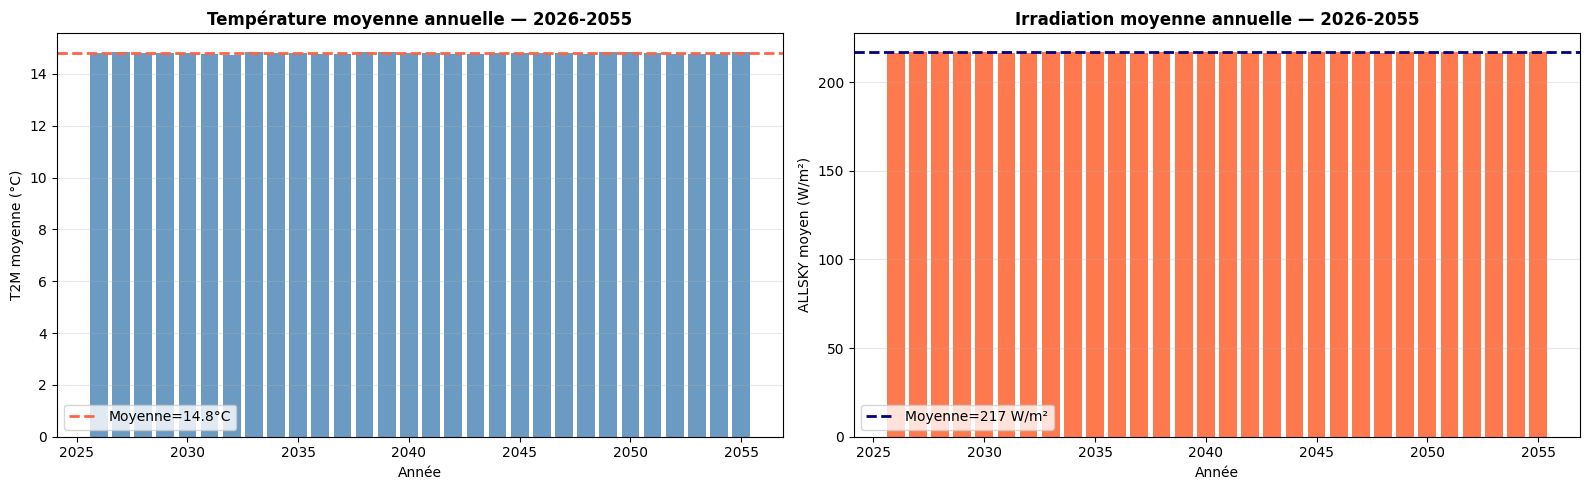

In [25]:
df_prev = pd.DataFrame({"T2M": y_fut_t, "ALLSKY": y_fut_s}, index=future_idx)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

annual_t = df_prev.groupby(df_prev.index.year)["T2M"].mean()
axes[0].bar(annual_t.index, annual_t.values, color="steelblue", alpha=0.8)
axes[0].axhline(y=annual_t.mean(), color="tomato", ls="--", lw=2, label=f"Moyenne={annual_t.mean():.1f}°C")
axes[0].set_xlabel("Année"); axes[0].set_ylabel("T2M moyenne (°C)")
axes[0].set_title("Température moyenne annuelle — 2026-2055", fontweight="bold")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

annual_s = df_prev.groupby(df_prev.index.year)["ALLSKY"].mean()
axes[1].bar(annual_s.index, annual_s.values, color="#FF5722", alpha=0.8)
axes[1].axhline(y=annual_s.mean(), color="navy", ls="--", lw=2, label=f"Moyenne={annual_s.mean():.0f} W/m²")
axes[1].set_xlabel("Année"); axes[1].set_ylabel("ALLSKY moyen (W/m²)")
axes[1].set_title("Irradiation moyenne annuelle — 2026-2055", fontweight="bold")
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()


## 14. Export CSV + Excel


In [26]:
# CSV horaire complet (30 ans) — valeurs à 2 décimales
pd.DataFrame({
    "Datetime": future_idx, "Year": future_idx.year, "Month": future_idx.month,
    "Day": future_idx.day, "Hour": future_idx.hour,
    "T2M_prevision_C": y_fut_t,
    "ALLSKY_prevision_Wm2": y_fut_s
}).to_csv("Prevision_30ans_Benguerir_2026_2055.csv", index=False, sep=";")
print("✓ Prevision_30ans_Benguerir_2026_2055.csv")

# Excel résumé multi-feuilles
metrics_df = comp.round(4)

params_df = pd.DataFrame({
    "Paramètre": ["Architecture", "Lookback (h)", "Optimizer", "Loss",
                   "Lag features", "Rolling features", "Mode prévision",
                   "Epochs", "Batch entraînement", "Batch prédiction",
                   "Patience EarlyStopping", "Clamp T2M", "Clamp ALLSKY",
                   "Réentraînement"],
    "Valeur": ["BiLSTM(128)→BiLSTM(64)→LSTM(32)→Dense(64)→Dense(32)→Dense(1)",
               str(LOOKBACK), "Adam (lr=0.001, clipnorm=1.0)", "Huber (δ=1.0)",
               "1h, 2h, 3h, 6h, 12h, 24h, 48h, 72h",
               "mean_24h, mean_72h, std_24h",
               "Autorégressive (rolling prediction → lags)",
               "50", "16", "32", "10",
               "[-10, 55] °C", "[0, 1200] W/m²",
               "NON — un seul entraînement utilisé pour la prévision"]
})

annual_export = pd.DataFrame({
    "Année": annual_t.index,
    "T2M_Moy_C": annual_t.values.round(2),
    "T2M_Max_C": df_prev.groupby(df_prev.index.year)["T2M"].max().values.round(2),
    "T2M_Min_C": df_prev.groupby(df_prev.index.year)["T2M"].min().values.round(2),
    "ALLSKY_Moy_Wm2": annual_s.values.round(2),
    "ALLSKY_Max_Wm2": df_prev.groupby(df_prev.index.year)["ALLSKY"].max().values.round(2),
    "Energie_kWh_m2": (df_prev.groupby(df_prev.index.year)["ALLSKY"].sum() / 1000).values.round(1)
})

monthly_export = df_prev.groupby([df_prev.index.year, df_prev.index.month]).agg(
    T2M_Moy=("T2M", "mean"), T2M_Max=("T2M", "max"), T2M_Min=("T2M", "min"),
    ALLSKY_Moy=("ALLSKY", "mean"), ALLSKY_Max=("ALLSKY", "max"),
    Energie_kWh_m2=("ALLSKY", lambda x: x.sum()/1000)
).round(2).reset_index()
monthly_export.columns = ["Année", "Mois", "T2M_Moy_C", "T2M_Max_C", "T2M_Min_C",
                            "ALLSKY_Moy_Wm2", "ALLSKY_Max_Wm2", "Energie_kWh_m2"]

with pd.ExcelWriter("Prevision_30ans_Benguerir_complet.xlsx", engine="openpyxl") as w:
    metrics_df.to_excel(w, sheet_name="Métriques_LSTM", index=False)
    params_df.to_excel(w, sheet_name="Hyperparamètres_LSTM", index=False)
    annual_export.to_excel(w, sheet_name="Résumé_Annuel", index=False)
    monthly_export.to_excel(w, sheet_name="Résumé_Mensuel", index=False)
print("✓ Prevision_30ans_Benguerir_complet.xlsx")

print(f"\n{'='*70}")
print("   TERMINÉ — Tous les fichiers générés avec succès")
print(f"{'='*70}")


✓ Prevision_30ans_Benguerir_2026_2055.csv
✓ Prevision_30ans_Benguerir_complet.xlsx

   TERMINÉ — Tous les fichiers générés avec succès
